# Kalman Filter on S&P 500

Kalman trend analysis for `^GSPC` using the history configured in Cell 2.

In [26]:
from pathlib import Path
import sys

import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(path for path in (cwd, *cwd.parents) if (path / "src" / "finance").exists())
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from finance.data import GSPC_SYMBOL, get_gspc_prices


def format_history_label(period: str) -> str:
    unit_names = {"d": "day", "mo": "month", "y": "year"}
    for unit, unit_name in unit_names.items():
        if period.endswith(unit):
            value = period[: -len(unit)]
            if value.isdigit():
                suffix = "" if value == "1" else "s"
                return f"{value}-{unit_name}{suffix} history"
    return f"{period} history"


history_period = "20y"
history_label = format_history_label(history_period)
chart_title = f"{GSPC_SYMBOL} close vs Kalman trend ({history_label})"

gspc_rows = get_gspc_prices(period=history_period, provider="yfinance")
gspc = pd.DataFrame(gspc_rows)
gspc["date"] = pd.to_datetime(gspc["date"], utc=True)
gspc = gspc.sort_values("date").reset_index(drop=True)

analysis_start = gspc["date"].min()
analysis_end = gspc["date"].max()

gspc[["date", "open", "high", "low", "close", "volume"]].tail()

,date,open,high,low,close,volume
5027,2026-04-13 00:00:00+00:00,6806.470215,6887.000000,6790.020020,6886.240234,4785840000
5028,2026-04-14 00:00:00+00:00,6910.200195,6969.419922,6905.169922,6967.379883,5032380000
5029,2026-04-15 00:00:00+00:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000
5030,2026-04-16 00:00:00+00:00,7037.779785,7051.229980,7008.520020,7041.279785,5173650000
5031,2026-04-17 00:00:00+00:00,7074.549805,7147.520020,7074.549805,7126.060059,6145300000


In [27]:
summary = {
    "symbol": GSPC_SYMBOL,
    "history_period": history_period,
    "history_label": history_label,
    "rows": len(gspc),
    "history_start": analysis_start,
    "history_end": analysis_end,
    "latest_close": float(gspc["close"].iloc[-1]),
}
summary

{'symbol': '^GSPC',
 'history_period': '20y',
 'history_label': '20-years history',
 'rows': 5032,
 'history_start': Timestamp('2006-04-18 00:00:00+0000', tz='UTC'),
 'history_end': Timestamp('2026-04-17 00:00:00+0000', tz='UTC'),
 'latest_close': 7126.06005859375}

In [28]:
def run_kalman_filter(series, process_variance, measurement_variance, initial_state_covariance=1.0):
    state_estimate = float(series.iloc[0])
    state_covariance = initial_state_covariance
    filtered_close = []
    kalman_gain = []

    for observed_price in series:
        predicted_estimate = state_estimate
        predicted_covariance = state_covariance + process_variance
        gain = predicted_covariance / (predicted_covariance + measurement_variance)
        state_estimate = predicted_estimate + gain * (observed_price - predicted_estimate)
        state_covariance = (1.0 - gain) * predicted_covariance
        filtered_close.append(state_estimate)
        kalman_gain.append(gain)

    return filtered_close, kalman_gain


prices = gspc[["date", "close"]].copy()
prices["observed_close"] = prices["close"].astype(float)

process_variance = 0.01
measurement_variance = 100.0

filtered_close, kalman_gain = run_kalman_filter(
    prices["observed_close"],
    process_variance=process_variance,
    measurement_variance=measurement_variance,
    initial_state_covariance=1.0,
)

prices["kalman_close"] = filtered_close
prices["noise"] = prices["observed_close"] - prices["kalman_close"]

prices.tail()

,date,close,observed_close,kalman_close,noise
5027,2026-04-13 00:00:00+00:00,6886.240234,6886.240234,6597.041966,289.198269
5028,2026-04-14 00:00:00+00:00,6967.379883,6967.379883,6600.726874,366.653009
5029,2026-04-15 00:00:00+00:00,7022.950195,7022.950195,6604.928049,418.022146
5030,2026-04-16 00:00:00+00:00,7041.279785,7041.279785,6609.269803,432.009982
5031,2026-04-17 00:00:00+00:00,7126.060059,7126.060059,6614.411931,511.648128


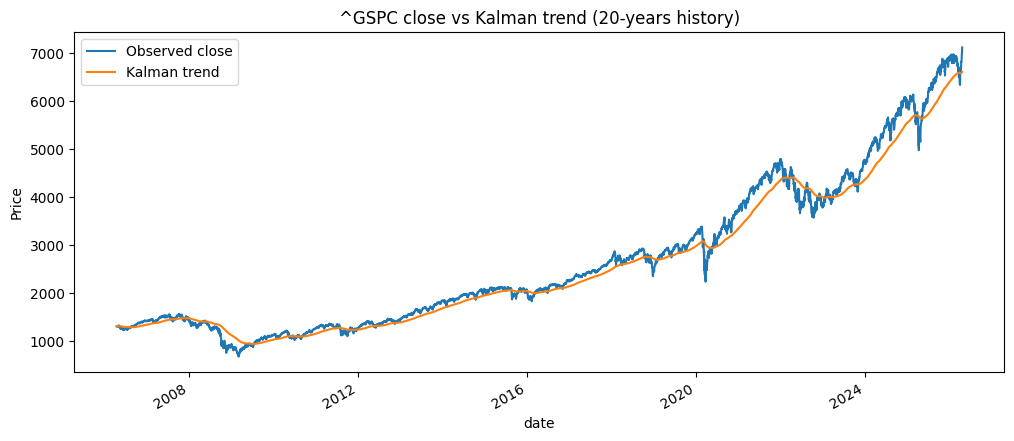

{'history_period': '20y',
 'history_label': '20-years history',
 'latest_observed_close': 7126.06005859375,
 'latest_kalman_close': 6614.411931004013,
 'latest_noise': 511.64812758973676,
 'noise_std': 195.1431490059321,
 'average_kalman_gain': 0.009950615023473861,
 'window_rows': 5032}

In [29]:
import matplotlib.pyplot as plt

ax = prices.plot(
    x="date",
    y=["observed_close", "kalman_close"],
    figsize=(12, 5),
    lw=1.5,
    title=chart_title,
)
ax.set_ylabel("Price")
ax.legend(["Observed close", "Kalman trend"])

metrics = {
    "history_period": history_period,
    "history_label": history_label,
    "latest_observed_close": float(prices["observed_close"].iloc[-1]),
    "latest_kalman_close": float(prices["kalman_close"].iloc[-1]),
    "latest_noise": float(prices["noise"].iloc[-1]),
    "noise_std": float(prices["noise"].std()),
    "average_kalman_gain": float(sum(kalman_gain) / len(kalman_gain)),
    "window_rows": len(prices),
}

plt.show()
metrics

In [30]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

full_prices = gspc[["date", "close"]].copy()
full_prices["observed_close"] = full_prices["close"].astype(float)


def render_kalman(process_variance=0.01, measurement_variance=100.0):
    interactive_prices = full_prices[["date", "observed_close"]].copy()
    filtered_close, kalman_gain = run_kalman_filter(
        interactive_prices["observed_close"],
        process_variance=process_variance,
        measurement_variance=measurement_variance,
        initial_state_covariance=1.0,
    )
    interactive_prices["kalman_close"] = filtered_close
    interactive_prices["noise"] = interactive_prices["observed_close"] - interactive_prices["kalman_close"]

    fig, ax = plt.subplots(figsize=(12, 5))
    interactive_prices.plot(
        ax=ax,
        x="date",
        y=["observed_close", "kalman_close"],
        lw=1.5,
        title=chart_title,
    )
    ax.set_ylabel("Price")
    ax.legend(["Observed close", "Kalman trend"])
    plt.show()

    metrics = {
        "process_variance": process_variance,
        "measurement_variance": measurement_variance,
        "latest_observed_close": float(interactive_prices["observed_close"].iloc[-1]),
        "latest_kalman_close": float(interactive_prices["kalman_close"].iloc[-1]),
        "latest_noise": float(interactive_prices["noise"].iloc[-1]),
        "noise_std": float(interactive_prices["noise"].std()),
        "average_kalman_gain": float(sum(kalman_gain) / len(kalman_gain)),
        "window_rows": len(interactive_prices),
    }
    display(metrics)


process_slider = widgets.FloatLogSlider(
    value=0.01,
    base=10,
    min=-4,
    max=2,
    step=0.1,
    description="Process",
    readout_format=".4f",
    continuous_update=False,
)
measurement_slider = widgets.FloatLogSlider(
    value=100.0,
    base=10,
    min=0,
    max=6,
    step=0.1,
    description="Measurement",
    readout_format=".1f",
    continuous_update=False,
)

slider_ui = widgets.VBox([
    widgets.HTML("<b>Kalman parameter explorer</b><br>Increase Measurement for more smoothing. Increase Process for faster trend changes."),
    process_slider,
    measurement_slider,
])
interactive_plot = widgets.interactive_output(
    render_kalman,
    {
        "process_variance": process_slider,
        "measurement_variance": measurement_slider,
    },
)

display(slider_ui, interactive_plot)

Output()

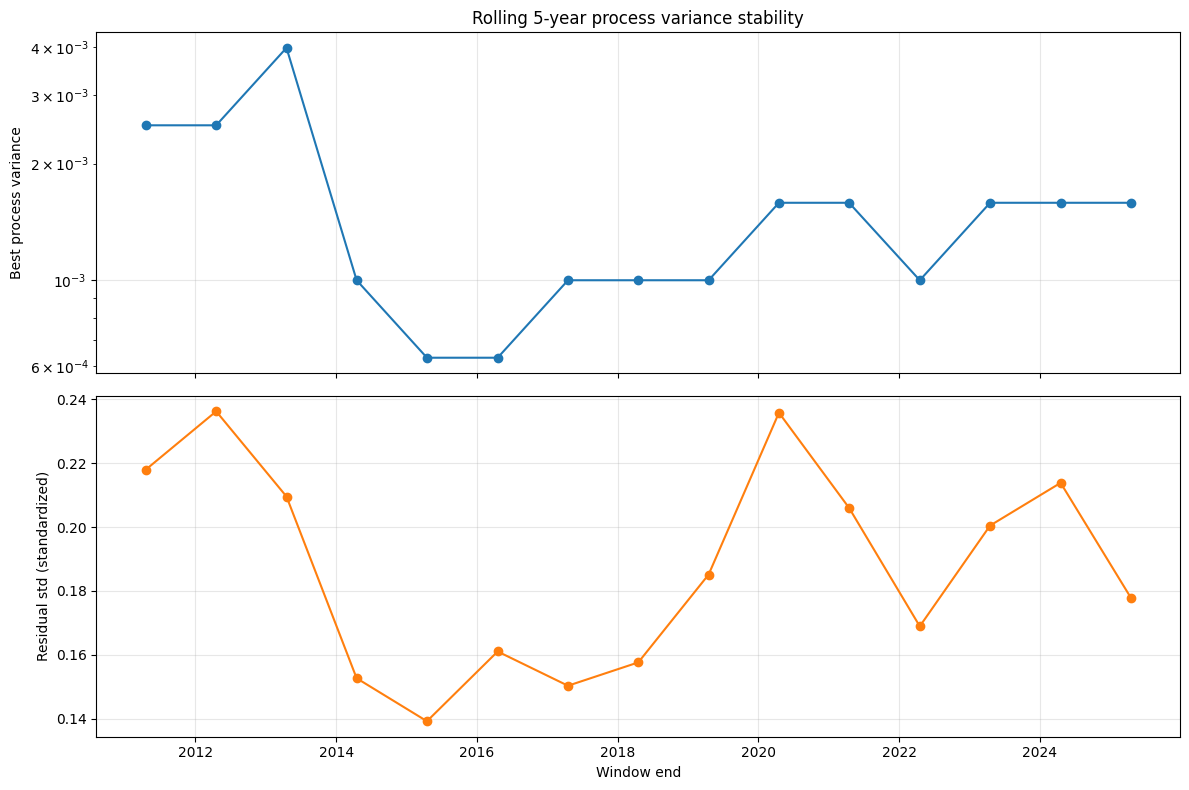

(                window_start                window_end  best_process_variance  \
 10 2016-04-18 00:00:00+00:00 2021-04-16 00:00:00+00:00               0.001585   
 11 2017-04-18 00:00:00+00:00 2022-04-18 00:00:00+00:00               0.001000   
 12 2018-04-18 00:00:00+00:00 2023-04-18 00:00:00+00:00               0.001585   
 13 2019-04-18 00:00:00+00:00 2024-04-18 00:00:00+00:00               0.001585   
 14 2020-04-20 00:00:00+00:00 2025-04-17 00:00:00+00:00               0.001585   
 
     stability_ratio_to_median  normalized_noise_std  
 10                   1.000000              0.206013  
 11                   0.630957              0.168932  
 12                   1.000000              0.200479  
 13                   1.000000              0.213853  
 14                   1.000000              0.177929  ,
 {'window_years': 5,
  'window_count': 15,
  'min_best_process_variance': 0.0006309573444801936,
  'median_best_process_variance': 0.001584893192461114,
  'max_best_process_va

In [31]:
import numpy as np



def kalman_log_likelihood(series, process_variance, measurement_variance=1.0, initial_state_covariance=1.0):
    state_estimate = float(series.iloc[0])
    state_covariance = initial_state_covariance
    log_likelihood = 0.0

    for observed_value in series:
        predicted_estimate = state_estimate
        predicted_covariance = state_covariance + process_variance
        innovation = observed_value - predicted_estimate
        innovation_variance = predicted_covariance + measurement_variance
        log_likelihood += -0.5 * (
            np.log(2.0 * np.pi * innovation_variance)
            + (innovation ** 2) / innovation_variance
        )
        gain = predicted_covariance / innovation_variance
        state_estimate = predicted_estimate + gain * innovation
        state_covariance = (1.0 - gain) * predicted_covariance

    return log_likelihood


window_years = 5
step_months = 12
candidate_process_variances = np.logspace(-6, 0, 31)
rolling_results = []
window_end = analysis_start + pd.DateOffset(years=window_years)

while window_end <= analysis_end:
    window_start = window_end - pd.DateOffset(years=window_years)
    window_prices = gspc.loc[
        (gspc["date"] >= window_start) & (gspc["date"] <= window_end),
        ["date", "close"],
    ].copy()

    if len(window_prices) < 252 * window_years * 0.8:
        window_end += pd.DateOffset(months=step_months)
        continue

    standardized_close = (window_prices["close"] - window_prices["close"].mean()) / window_prices["close"].std()
    log_likelihoods = [
        kalman_log_likelihood(standardized_close, process_variance=value)
        for value in candidate_process_variances
    ]
    best_index = int(np.argmax(log_likelihoods))
    best_process_variance = float(candidate_process_variances[best_index])
    filtered_window, _ = run_kalman_filter(
        standardized_close,
        process_variance=best_process_variance,
        measurement_variance=1.0,
        initial_state_covariance=1.0,
    )
    filtered_window = pd.Series(filtered_window, index=window_prices.index)

    rolling_results.append(
        {
            "window_start": window_prices["date"].iloc[0],
            "window_end": window_prices["date"].iloc[-1],
            "best_process_variance": best_process_variance,
            "log_likelihood": float(log_likelihoods[best_index]),
            "normalized_noise_std": float((standardized_close - filtered_window).std()),
            "rows": len(window_prices),
        }
    )
    window_end += pd.DateOffset(months=step_months)

rolling_windows = pd.DataFrame(rolling_results)
rolling_windows["stability_ratio_to_median"] = (
    rolling_windows["best_process_variance"] / rolling_windows["best_process_variance"].median()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(
    rolling_windows["window_end"],
    rolling_windows["best_process_variance"],
    marker="o",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Best process variance")
axes[0].set_title("Rolling 5-year process variance stability")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    rolling_windows["window_end"],
    rolling_windows["normalized_noise_std"],
    marker="o",
    color="tab:orange",
)
axes[1].set_ylabel("Residual std (standardized)")
axes[1].set_xlabel("Window end")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

stability_summary = {
    "window_years": window_years,
    "window_count": len(rolling_windows),
    "min_best_process_variance": float(rolling_windows["best_process_variance"].min()),
    "median_best_process_variance": float(rolling_windows["best_process_variance"].median()),
    "max_best_process_variance": float(rolling_windows["best_process_variance"].max()),
    "max_to_min_ratio": float(
        rolling_windows["best_process_variance"].max()
        / rolling_windows["best_process_variance"].min()
    ),
    "latest_best_process_variance": float(rolling_windows["best_process_variance"].iloc[-1]),
}

rolling_windows[[
    "window_start",
    "window_end",
    "best_process_variance",
    "stability_ratio_to_median",
    "normalized_noise_std",
]].tail(), stability_summary

In [32]:
regime_takeaway = {
    "median_best_process_variance": float(rolling_windows["best_process_variance"].median()),
    "max_to_min_ratio": float(
        rolling_windows["best_process_variance"].max()
        / rolling_windows["best_process_variance"].min()
    ),
    "windows_outside_half_to_double_median": int(
        (~rolling_windows["best_process_variance"].between(
            rolling_windows["best_process_variance"].median() * 0.5,
            rolling_windows["best_process_variance"].median() * 2.0,
        )).sum()
    ),
}
regime_takeaway["interpretation"] = (
    "Process variance is moving enough across rolling windows that the trend is regime-dependent, not fully stable."
    if regime_takeaway["max_to_min_ratio"] > 3.0
    else "Process variance is fairly stable across rolling windows."
)

rolling_windows[[
    "window_end",
    "best_process_variance",
    "stability_ratio_to_median",
    "normalized_noise_std",
]], regime_takeaway

(                  window_end  best_process_variance  \
 0  2011-04-18 00:00:00+00:00               0.002512   
 1  2012-04-18 00:00:00+00:00               0.002512   
 2  2013-04-18 00:00:00+00:00               0.003981   
 3  2014-04-17 00:00:00+00:00               0.001000   
 4  2015-04-17 00:00:00+00:00               0.000631   
 5  2016-04-18 00:00:00+00:00               0.000631   
 6  2017-04-18 00:00:00+00:00               0.001000   
 7  2018-04-18 00:00:00+00:00               0.001000   
 8  2019-04-18 00:00:00+00:00               0.001000   
 9  2020-04-17 00:00:00+00:00               0.001585   
 10 2021-04-16 00:00:00+00:00               0.001585   
 11 2022-04-18 00:00:00+00:00               0.001000   
 12 2023-04-18 00:00:00+00:00               0.001585   
 13 2024-04-18 00:00:00+00:00               0.001585   
 14 2025-04-17 00:00:00+00:00               0.001585   
 
     stability_ratio_to_median  normalized_noise_std  
 0                    1.584893              0.2